In [11]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

### Defining PDE

In [4]:
def pde(x, u):
    du_xx = dde.grad.hessian(u, x, i=0, j=0);
    du_yy = dde.grad.hessian(u, x, i=0, j=1);

    return -1*(du_xx + du_yy) -1


### Defining Boundary

In [ ]:
geom = dde.geometry.Rectangle([-5, 5], [5, 10])

bc_left = dde.icbc.DirichletBC(
    geom,
    lambda x : 7,
    lambda x, on_boundary: on_boundary and np.isclose(x[0], -5)
)

bc_right = dde.icbc.DirichletBC(
    geom,
    lambda x : 21,
    lambda x, on_boundary: on_boundary and np.isclose(x[0], 5)
)

bc_down = dde.icbc.DirichletBC(
    geom,
    lambda x : 11,
    lambda x, on_boundary: on_boundary and np.isclose(x[1], 5)
)
bc_up = dde.icbc.DirichletBC(
    geom,
    lambda x : 22,
    lambda x, on_boundary: on_boundary and np.isclose(x[1], 10)
)


### Defining Data and Net

In [9]:
data = dde.data.PDE(
    geom,
    pde,
    [bc_left, bc_right, bc_down, bc_up],
    num_domain=1000,
    num_boundary=200,
    num_test=100
)


net = dde.nn.FNN(
    [2] + [64]*4 + [1],
    "tanh",
    "Glorot normal"
)

model = dde.Model(data, net)

In [ ]:
model.compile("adam", 0.001)
model.train(iterations=10000)

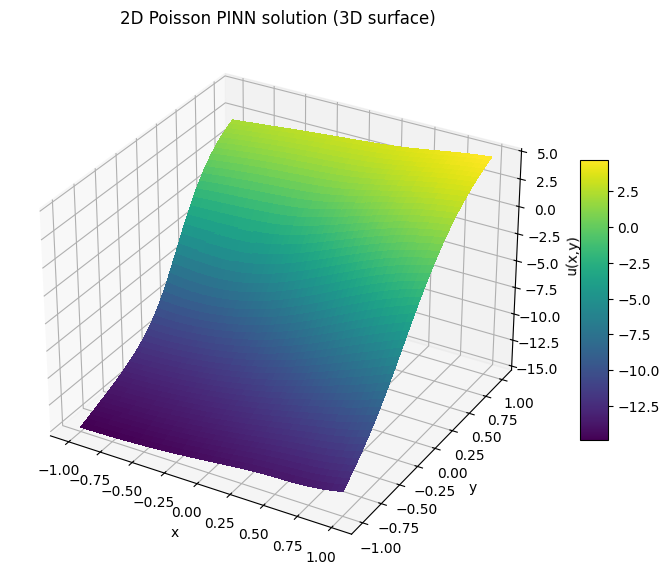

In [18]:
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-1, 1, 50)
y = np.linspace(-1, 1, 50)
xx, yy = np.meshgrid(x, y)
xy = np.column_stack([xx.ravel(), yy.ravel()])

u_pred = model.predict(xy).reshape(50, 50)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xx, yy, u_pred, cmap="viridis", linewidth=0, antialiased=False)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_title("2D Poisson PINN solution (3D surface)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u(x,y)")
plt.tight_layout()
plt.show()